Use this script to look at the fraction of tuned cells to %escape in different conditions after removing cells whose tuning can be explained by distance to shelter in exploration or homing/escape 

We aim to compare which cells are tuned across conditions and what they are tuned to across conditions

- sig tuned to %escape and shelter distance in explore
- sig tuned to %escape and shelter distance in homing/escape
- triple overlap cells

In [ ]:
from behave_analysis.database.Experiments.JAL003_ex import JAL3_25aug, JAL3_1sept, JAL3_4sept, JAL3_7sept, JAL3_22aug

from behave_analysis.database.Experiments.JAL004_ex import JAL4_3rdSept, JAL4_19thSept, JAL4_11thSept, JAL4_28aug

from behave_analysis.database.Experiments.JAL005_ex import JAL005_8thSept, JAL005_21stSept, JAL005_5thSept

from behave_analysis.database.Experiments.JAL006_ex import JAL6_flip3_18mar, JAL6_flip7_1apr, JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar

from behave_analysis.database.Experiments.JAL007_ex import JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr

from behave_analysis.database.Experiments.JAL008_ex import JAL8_flip3_7may, JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_flip4_10may, JAL8_14may

# JAL3_7sept, JAL3_4sept, JAL3_1sept, JAL3_25aug, JAL3_22aug,
# "JAL3_7sept", "JAL3_4sept", "JAL3_1sept", "JAL3_25aug", "JAL3_22aug",

experiments_objects = [JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept,
JAL005_8thSept, JAL005_21stSept, # JAL005_5thSept this one doesn't flip, but can be used as first barrier appearance
JAL6_28mar, JAL6_flip4_21mar, JAL6_flip3_18mar, JAL6_flip5_25mar, # (unmatched number of neurons and cluster ids) # JAL6_flip7_1apr, # this session is sus
JAL7_sesh8_9apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_sesh9_16apr, JAL7_23apr,
JAL8_flip1_25apr,JAL8_flip2_29apr, JAL8_flip3_7may, JAL8_14may, JAL8_flip4_10may]

In [2]:
%load_ext autoreload
from behave_analysis.utils.creating_directories import make_directory
from behave_analysis.process.process import Process

import os
import numpy as np
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
from pathlib import Path
import dill as pickle
from itertools import product

%matplotlib inline

In [ ]:
# """Load in hdir cells"""
# dir = Path("Z:\Jasmine_Laurence\single_trial_overview\decoding_spatial_efficiency\head_direction_cells.pkl")
# with open(dir, "rb") as dill_file:
#     hdir = pickle.load(dill_file)

# """Compare to hdir"""

# for idx, exp in enumerate(experiments_objects):
#     if np.sum(sesh_vector == (idx+1)) > 0:
#             # load in cluster Ids
#         session = Process(exp).load_session()
#         base_path = os.path.join(session.base_path, session.processed_path)
#         clu_Ids = np.load(os.path.join(session.base_path, session.processed_path)
#             + "\\"
#             + "good_cluster_Ids.npy"
#         )

#         # double check that it is the same length as the one we got from 
#         if len(clu_Ids) == np.sum(sesh_vector == (idx+1)):
#             # make a zeros vector of n_neur, make hdirs 1s
#             sesh_hdir = np.zeros(len(clu_Ids))
#             # find the name of the dict key, and which ones are the hdir cells
#             hdir_n = hdir[session_names[idx]]
#             hdir_idx = [int(np.where(clu_Ids == int(x))[0][0]) for x in hdir_n]
#             sesh_hdir[hdir_idx] = 1
#             # save the hdir vector and the session id vector
#             if idx == 0:
#                 hdir_sesh_vector = np.ones(len(clu_Ids))
#                 all_sesh_hdir = sesh_hdir
#             else:
#                 hdir_sesh_vector = np.hstack((hdir_sesh_vector, np.ones(len(clu_Ids)) * (idx+1)))
#                 all_sesh_hdir = np.hstack((all_sesh_hdir, sesh_hdir))
#         else:
#             print('This session has unmatched number of neurons: ' + session_names[idx])
#     else:
#             print('This session is empty: ' + session_names[idx])

# print(len(all_sesh_hdir), len(hdir_sesh_vector), len(sesh_vector), np.shape(sig_cell_dict['escape']))

C:\Users\Jasmine\AppData\Local\Temp\ipykernel_2532\1192446070.py:126: RuntimeWarning: invalid value encountered in divide
  hist_all[e,:,idx] = hist_all[e,:,idx]/np.sum(hist_all[e,:,idx])


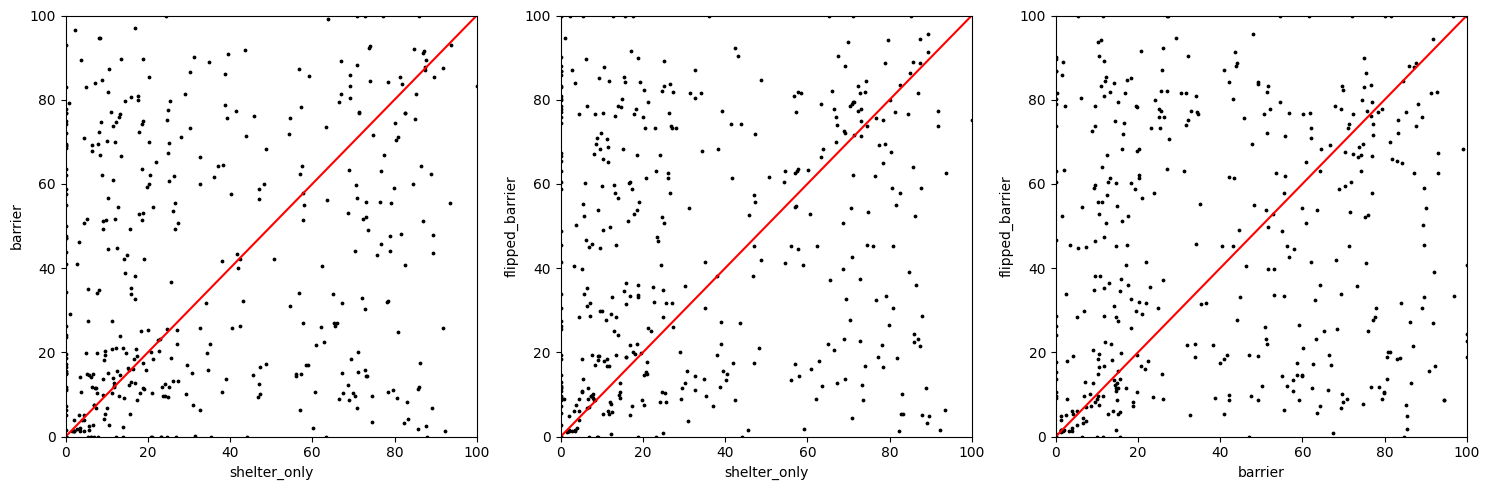

In [ ]:
"""How many cells are tuned only to the %escape and not to the distance to shelter in exploration?
Using residuals to identify tuning to %escape surviving from distance to shelter subtraction"""

case = 'either_tuned' # 'escape_tuned', 'dist_tuned', 'either_tuned
condition = 'barrier_both' # 'shelter_only', 'barrier', 'flipped_barrier', 'all', 'barrier_both'
hist_bins = np.arange(-105,105,10)
hist_all = np.full((len(experiments_objects),len(hist_bins)-1,3), np.nan)

fig, axs = plt.subplots(1, 3, figsize = (15, 5))
cond = [[0,0,1],[1,2,2]]
c_names = ['shelter_only', 'barrier', 'flipped_barrier']
for idx, ax in enumerate(axs):
    ax.set_xlabel(c_names[cond[0][idx]])
    ax.set_ylabel(c_names[cond[1][idx]])
    ax.plot([0,100],[0,100], color = 'red')
    if case == 'escape_tuned':
        ax.set_xlim([0,100])
        ax.set_ylim([0,100])
    elif case == 'dist_tuned':
        ax.set_xlim([0,80])
        ax.set_ylim([0,80])
    elif case == 'either_tuned':
        ax.set_xlim([0,100])
        ax.set_ylim([0,100])

for e, exp in enumerate(experiments_objects):
    nickname = exp.nick_name + '_' + exp.experiment_date

    # 1. load in explore tuning curve
    exp_nickname = exp.nick_name + '_' + exp.experiment_date + '_' + 'bird_dist_shelter'
    dump_path = make_directory("Z:/Jasmine_Laurence/summary_plots/tuning_curves_explore/")
    saving_file = dump_path + exp_nickname + '_Tuning.npz'
    data = np.load(saving_file)

    # pull out the params
    exp_params_real = data['params_real']
    exp_params_shifts = data['params_shifts']

    # identify cells that are sig tuned to distance to shelter in exploration
    exp_sig_dist = exp_params_real[:,:,0] > np.nanpercentile(exp_params_shifts[:,:,:,0], 95, axis = 0)

    # 2. load in escape homing/escape tuning curve
    exp_nickname = exp.nick_name + '_' + exp.experiment_date + '_' + 'escape'
    dump_path = make_directory("Z:/Jasmine_Laurence/summary_plots/tuning_curves/")
    saving_file = dump_path + exp_nickname + '_ProperTuning.npz'
    data = np.load(saving_file)

    fr_esc = data['fr_real']
    params_esc = data['params_real']
    params_esc_shift = data['params_shifts']

    # identify cells that are sig tuned to %escape in homing/escape
    sig_escape = params_esc[:,:,0] > np.nanpercentile(params_esc_shift[:,:,:,0], 95, axis = 0)

    # 2. load in dist to shelter homing/escape tuning curve
    exp_nickname = exp.nick_name + '_' + exp.experiment_date + '_' + 'bird_dist_shelter'
    dump_path = make_directory("Z:/Jasmine_Laurence/summary_plots/tuning_curves/")
    saving_file = dump_path + exp_nickname + '_ProperTuning.npz'
    data = np.load(saving_file)

    fr_dist = data['fr_real']
    params_dist = data['params_real']
    params_dist_shifts = data['params_shifts']

    # identify cells that are sig tuned to %escape in homing/escape
    sig_dist = params_dist[:,:,0] > np.nanpercentile(params_dist_shifts[:,:,:,0], 95, axis = 0)

    # 4. load in residuals data
    dump_path = make_directory("Z:/Jasmine_Laurence/summary_plots/tuning_curves/")
    exp_nickname = exp.nick_name + '_' + exp.experiment_date + '_' + 'escape'
    saving_file = dump_path + exp_nickname + '_ResidualsTuning.npz'
    data = np.load(saving_file)
    params_real_exp = data['params_real_exp']
    params_shifts_exp_res = data['params_shifts_exp_res']

    # find cells whose residual tuning to %escape - distance to shelter in exploration is significant
    sig_res = params_real_exp[:,:,0] > np.nanpercentile(params_shifts_exp_res[:,:,:,0], 95, axis = 0)

    """Select the cells I want to analyse"""
    if case == 'escape_tuned':
        # cells that are tuned to %escape in homing/escape (subselect ones that are not tuned to distance to shelter in exploration and passed the residual test)
        xval = np.full_like(sig_escape, np.nan)
        for c in range(3):
            A = (sig_escape[:, c] == True) & (exp_sig_dist[:, c] == False) & (sig_res[:, c] == False)  # V1 only
            AC = (sig_escape[:, c] == True) & (sig_res[:, c] == True)  # Both V1 and V1 regressed
            xval[:,c] = (A == True) | (AC == True)

    if case == 'dist_tuned':
        # cells that are tuned to distance to shelter in homing/escape (subselect ones that are not tuned to %escape in homing/escape)
        xval = np.full_like(sig_escape, np.nan)
        for c in range(3):
            A = (sig_dist[:, c] == True)
            B = (sig_dist[:, c] == True) & (exp_sig_dist[:,c] == False)
            xval[:,c] = (A == True) # xval[:,c] = (B == True)
    
    if case == 'either_tuned':
        # cells that are tuned to distance to shelter or %escape in homing/escape (subselect ones that are not tuned to distance to shelter in exploration and passed the residual test)
        xval = np.full_like(sig_escape, np.nan)
        for c in range(3):
            A = (sig_escape[:, c] == True) & (exp_sig_dist[:, c] == False) & (sig_res[:, c] == False)
            AC = (sig_escape[:, c] == True) & (sig_res[:, c] == True) # Both V1 and V1 regressed
            B = (sig_dist[:, c] == True)
            xval[:,c] = (A == True) | (AC == True) | (B == True)

    if condition == 'all':
        cells = np.sum(xval, axis = 1) == 3
    elif condition == 'shelter_only':
        cells = xval[:,0] == True
    elif condition == 'barrier':
        cells = xval[:,1] == True
    elif condition == 'flipped_barrier':
        cells = xval[:,2] == True
    elif condition == 'barrier_both':
        cells = (xval[:,0] == False) & (xval[:,1] == True) & (xval[:,2] == True)

    cond = [[0,0,1],[1,2,2]]
    for idx in range(3):
        if case == 'escape_tuned':
            diff = params_esc[cells, cond[0][idx], 1] - params_esc[cells, cond[1][idx], 1]
        elif case == 'dist_tuned':
            diff = params_dist[cells, cond[0][idx], 1] - params_dist[cells, cond[1][idx], 1]
        elif case == 'either_tuned':
            diff = params_dist[cells, cond[0][idx], 1] - params_dist[cells, cond[1][idx], 1]
        hist_all[e,:,idx], _ = np.histogram(diff, bins = hist_bins)
        hist_all[e,:,idx] = hist_all[e,:,idx]/np.sum(hist_all[e,:,idx])
    
    """Make a scatter plot of the preferred tuning of the cells across conditions"""

    for idx, ax in enumerate(axs):
        if case == 'escape_tuned':
            ax.scatter(params_esc[cells, cond[0][idx], 1], params_esc[cells, cond[1][idx], 1], s = 3, color = 'black')
        elif case == 'dist_tuned':
            ax.scatter(params_dist[cells, cond[0][idx], 1], params_dist[cells, cond[1][idx], 1], s = 3, color = 'black')
        elif case == 'either_tuned':
            ax.scatter(params_esc[cells, cond[0][idx], 1], params_esc[cells, cond[1][idx], 1], s = 3, color = 'black')

plt.tight_layout()

Groups of things we can look at:
1. Look at cells that are significant in all three conditions (or in 2/3 conditions)
    - what are they tuned to in each? make a heatmap of the sorted tuning curves
    - make sorted heatmaps of responses on different types of trials (homings to barrier, north vs south homings)
    - plot the preferred tuning aganst each other
2. Look at cells that are significant in one condition
    - basically a lot of the same types of plots

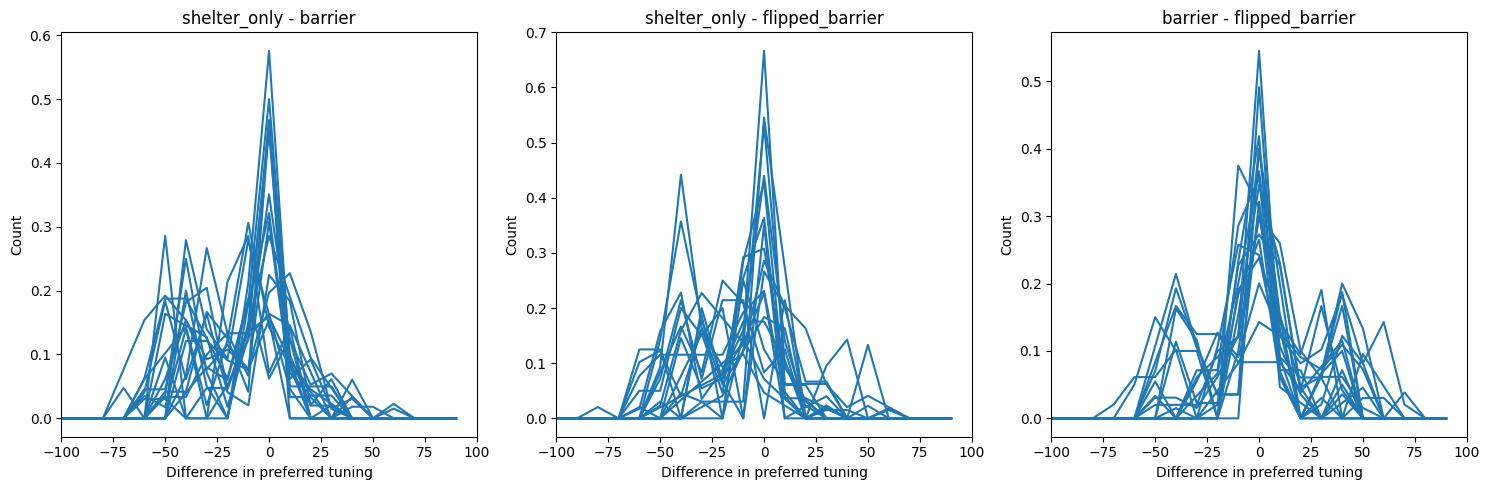

In [26]:
""""Make a histogram of the difference in preferred tuning between conditions"""

fig, axs = plt.subplots(1, 3, figsize = (15, 5))
c_names = ['shelter_only', 'barrier', 'flipped_barrier']
bin_center = hist_bins[:-1] + np.diff(hist_bins)/2
for idx, ax in enumerate(axs):
    ax.plot(bin_center, hist_all[:,:,idx].T, color = 'C0')
    ax.set_title(c_names[cond[0][idx]] + ' - ' + c_names[cond[1][idx]])
    ax.set_xlim([-100,100])
    ax.set_xlabel('Difference in preferred tuning')
    ax.set_ylabel('Count')

plt.tight_layout()